# Notebook 4 · Artificial test-takers, classical statistics and IRT

1. **Administer** the Day-1 items to the model as a *fixed form*: the same booklet, same order,
   for every test-taker. A test-taker is an ability prompt (a CEFR persona) plus a seed.
2. Build the **response matrix** (test-takers × items) and score it.
3. **Classical test theory**: facility, item–total correlation, Cronbach's α, and how the
   distractors behave.
4. Fit a **Rasch** and a **2PL** model (the EM algorithm written out in numpy).
5. **Correlate** the empirical difficulties with the predictions from Notebook 3.

One warning up front: a capable language model does not become a weak reader because a prompt
tells it to. With one model behind all personas, every test-taker from A2 to C2 answered every item correctly in the
reference run — a matrix of ones, no statistics. The test-takers therefore differ in two ways here: the
persona prompt and the *size of the model* that answers (0.6B to 30B parameters). Look at the matrix before
fitting any model.

*Notebook by Rasmus Jensen (ETH Zurich), adapted for the fall school by Rudolf Debelak (EPFL). The pipeline follows Jensen (2025, 2026).*


## Setup

Three things to fill in: the endpoint, the key, and the two model names (one model writes the
passages, one writes and judges the items). On Colab, store the key once under the key icon on
the left (*Secrets*) as `AIG_API_KEY` and the endpoint as `AIG_BASE_URL`; the cell reads them
from there. Everything else in the notebook only uses the three small helpers defined below:

* `render(template, **values)` fills a prompt template — `{{level}}` in the template becomes the
  value of `level`.
* `ask(system, user, schema)` sends one system message and one user message to the model. If a
  `schema` (a pydantic class) is given, the server is asked to reply in that JSON layout and the
  reply comes back as an object of that class, so the rest of the code never parses text.
  Every call is stored in `cache/`; an identical call is replayed from disk, so a notebook that
  has been run once runs again without the endpoint (set `OFFLINE = True` to enforce that).
  Failed calls are retried; a reply that does not fit the schema is asked for once more.
* `ask_many(calls)` runs a list of such calls in parallel, because a pipeline step usually asks
  the same question about many items.


In [ ]:
%pip install -q openai pydantic jinja2 pandas

import json, re, os, time, hashlib
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor
from openai import OpenAI
from pydantic import BaseModel, Field, ValidationError
from jinja2 import Template
import pandas as pd

# --- endpoint, key, models -----------------------------------------------------------------
BASE_URL   = os.environ.get("AIG_BASE_URL", "https://YOUR-ENDPOINT/v1")   # the OpenAI-compatible endpoint
API_KEY    = os.environ.get("AIG_API_KEY", "EMPTY")
try:                                                     # on Colab: read both from the Secrets panel
    from google.colab import userdata
    API_KEY  = userdata.get("AIG_API_KEY") or API_KEY
    BASE_URL = userdata.get("AIG_BASE_URL") or BASE_URL
except Exception:
    pass
TEXT_MODEL = "swiss-ai/Apertus-v1.5-70B"              # writes the passages
ITEM_MODEL = "Qwen/Qwen3-30B-A3B-Instruct-2507"       # writes and judges the items; the `reasoning` fields in the schemas carry its chain of thought

# --- cache: every call is stored; identical calls are replayed ------------------------------
CACHE_DIR = Path("cache"); CACHE_DIR.mkdir(exist_ok=True)
OFFLINE   = False                                     # True: never call the endpoint, only replay

client = OpenAI(base_url=BASE_URL, api_key=API_KEY, timeout=240, max_retries=0)


def render(template, **values):
    return Template(template).render(**values)          # {{name}} in the template -> values[name]


def _parse(text, schema):
    text = re.sub(r"<think>.*?</think>", "", text, flags=re.S)   # thinking models: drop the reasoning block
    text = re.sub(r"```(?:json)?", "", text).strip()              # and code fences
    if schema is None:
        return text
    data = json.loads(text)
    if isinstance(data, list) and len(data) == 1:                # some models wrap the object in a list
        data = data[0]
    return schema.model_validate(data)


def ask(system, user, schema=None, model=None, temperature=0.4, seed=None, think=None, max_tokens=4096, retries=3):
    """One system + one user message -> plain text, or an instance of `schema`."""
    payload = dict(model=model or ITEM_MODEL, temperature=temperature, max_tokens=max_tokens,
                   messages=[{"role": "system", "content": system}, {"role": "user", "content": user}])
    if schema is not None:                                        # ask the server for the schema's JSON layout
        payload["response_format"] = {"type": "json_schema",
                                      "json_schema": {"name": schema.__name__, "schema": schema.model_json_schema()}}
    if seed is not None:
        payload["seed"] = seed
    if think is not None:                                         # thinking on/off for Qwen3 hybrid models (vLLM); a no-op for Instruct / Thinking-only models
        payload["extra_body"] = {"chat_template_kwargs": {"enable_thinking": bool(think)}}

    path = CACHE_DIR / (hashlib.sha256(json.dumps(payload, sort_keys=True).encode()).hexdigest()[:24] + ".json")
    for attempt in range(retries):
        cached = None
        if path.exists():
            try:
                cached = json.loads(path.read_text(encoding="utf-8"))["text"]
            except (OSError, ValueError):                         # half-written by a parallel call: treat as missing
                cached = None
        if cached is not None:
            text = cached
        elif OFFLINE:
            raise RuntimeError(f"OFFLINE and not in cache: {user[:80]!r}")
        else:
            try:
                reply = client.chat.completions.create(**payload)
                msg = reply.choices[0].message
                text = msg.content or getattr(msg, "reasoning_content", None) or ""   # some servers file a no-thinking reply under reasoning_content
            except Exception as e:                                # connection / server error: wait and retry
                time.sleep(3 * (attempt + 1))
                if attempt == retries - 1:
                    raise RuntimeError(f"endpoint failed {retries} times: {e}") from e
                continue
            tmp = path.with_name(path.name + f".{os.getpid()}.{id(payload)}.tmp")   # atomic write: parallel calls never see a half file
            tmp.write_text(json.dumps({"text": text, "payload": payload}, ensure_ascii=False), encoding="utf-8")
            os.replace(tmp, path)
        try:
            return _parse(text, schema)
        except (json.JSONDecodeError, ValidationError) as e:      # reply did not fit: drop it from the cache, ask again
            path.unlink(missing_ok=True)
            payload["temperature"] = 0.2
            if attempt == retries - 1:
                raise RuntimeError(f"reply did not match {schema.__name__}: {e}\n{text[:300]}") from e


def ask_many(calls, workers=6):                         # calls: list of dicts with ask()'s arguments
    with ThreadPoolExecutor(workers) as pool:
        return list(pool.map(lambda c: ask(**c), calls))


def need_file(name):
    """Make sure `name` exists in the session: on Colab, offer an upload dialog if it is missing."""
    if not Path(name).exists():
        try:
            from google.colab import files
            print(f"{name} not found - please upload it:")
            files.upload()
        except Exception:
            raise FileNotFoundError(f"{name} not found in the working directory")
    return name


Note: you may need to restart the kernel to use updated packages.


In [2]:
PERSONAS = {
    'A2': 'an elementary learner (CEFR A2) who understands only short, simple texts and frequent words, and often guesses from single familiar words',
    'B1': "an intermediate learner (CEFR B1) who understands the main points of clear texts but misses implied meaning and the writer's attitude",
    'B2': 'an upper-intermediate learner (CEFR B2) who follows arguments and simple inferences but sometimes misses subtle attitude or distant connections in a text',
    'C1': 'an advanced learner (CEFR C1) who understands long, demanding texts and implicit meaning',
    'C2': 'a learner with full mastery (CEFR C2) who reads everything with ease and weighs every option carefully',
}

MATH_PERSONAS = {
    'A2': 'a 12-year-old who has just met percentages, often confuses the amount of a change with the percentage, and guesses when unsure',
    'B1': 'a 13-year-old who can compute a percentage of a number but often takes the wrong base when comparing two prices',
    'B2': 'a 14-year-old who usually solves percentage problems correctly but slips on multi-step ones',
    'C1': 'a 16-year-old who solves percentage problems reliably',
    'C2': 'a maths teacher who checks every step',
}

TAKER_MODELS = {                                                     # ability by model size: a prompt alone does not make a strong model weak
    "A2": "Qwen/Qwen3-0.6B", "B1": "Qwen/Qwen3-1.7B", "B2": "Qwen/Qwen3-4B", "C1": "Qwen/Qwen3-8B", "C2": ITEM_MODEL,
}

PERSONA_SYSTEM = """You are taking an English reading test as {{persona}}.
Answer every question the way such a learner would, including the mistakes typical of that level. Do not use reading skills beyond that level.
Choose exactly one option per question; guess if unsure."""

MATH_PERSONA_SYSTEM = """You are taking a maths test as {{persona}}.
Answer every question the way such a student would, including the mistakes typical of that student. Do not use skills beyond that level.
Choose exactly one option per question; guess if unsure."""

MATH_FORM_PROMPT = """Questions:
{% for it in items %}{{loop.index}}. {{it.question}}
{% for L, opt in it.options.items() %}   {{L}}) {{opt}}
{% endfor %}{% endfor %}
Give one letter per question, in the order given."""

FORM_PROMPT = """Passage:
{{text}}

Questions:
{% for it in items %}{{loop.index}}. {{it.question}}
{% for L, opt in it.options.items() %}   {{L}}) {{opt}}
{% endfor %}{% endfor %}
Give one letter per question, in the order given."""

## Load items and predictions

`day2_screened_items.json` (Notebook 3) has the items with their screening flags;
`day1_predictions.json` the predicted difficulties. Upload both.

In [3]:
%pip install -q numpy scipy matplotlib
import random
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, pearsonr, spearmanr
from scipy.special import expit
from scipy.optimize import minimize

with open(need_file("day2_screened_items.json"), encoding="utf-8") as f:
    data = json.load(f)
with open(need_file("day1_predictions.json"), encoding="utf-8") as f:
    predicted = json.load(f)["items"]

passages = {p["id"]: p for p in data["passages"]}
items = data["items"]                                                      # reading and math items
by_id = {it["id"]: it for it in items}
n_math = sum(it.get("cat") == "MATH" for it in items)
print(len(items) - n_math, "reading items,", n_math, "math items,", len(passages), "passages,", len(predicted), "predictions")

Note: you may need to restart the kernel to use updated packages.
10 reading items, 10 math items, 3 passages, 10 predictions


## The fixed form and the artificial test-takers

`make_form()` groups the items by passage, in file order: one booklet per passage, items in a
fixed order — the way a paper test is administered; the math items form one extra booklet without
a passage. `booklet_call(persona, seed, block)` builds one call: the system message says which
learner the model is (`PERSONAS`, or `MATH_PERSONAS` for the math booklet), the user message
holds the passage and the numbered questions with their options, and the `Answers` schema
returns one letter per question. The seed is passed to the endpoint, so a test-taker is
reproducible.

The persona prompt alone does not produce ability differences: in the reference run with one model
behind every persona, all twenty test-takers scored 20/20. So each level is also answered by a
different model (`TAKER_MODELS`): a 0.6B-parameter model for A2 up to the 30B item model for C2.
Model size stands in for ability — Liu et al. (2025) use the same idea with a set of models of
different strength — and the persona prompt keeps the framing. Thinking is switched off for the
test-takers, so the small models answer quickly.

`personas × seeds × booklets` calls in total (5 × 4 × 4 = 80 by default).

**Stretch (off by default):** `MASK_RATE` degrades the *input* instead of the reader: for each persona a share of the passage's
content words is blanked out before the model sees it, so that ability is induced by what the
reader can access rather than by instruction. Set the dict to non-zero rates to try it, or set every entry of
`TAKER_MODELS` to `ITEM_MODEL` to see the persona-only matrix for yourself (needs the endpoint).


In [4]:
N_SEEDS   = 4                                                    # test-takers per persona
MASK_RATE = {"A2": 0.0, "B1": 0.0, "B2": 0.0, "C1": 0.0, "C2": 0.0}  # stretch: e.g. {"A2": .35, "B1": .2, "B2": .1, "C1": .03, "C2": 0}


class Answers(BaseModel):
    answers: list[str] = Field(description="One letter (A, B, C or D) per question, in the order given.")


def mask_text(text, rate, seed):                                 # blank out a share of the content words
    if rate <= 0:
        return text
    rng, tokens = random.Random(seed), text.split()
    idx = [i for i, t in enumerate(tokens) if len(re.sub(r"\W", "", t)) >= 4]
    for i in rng.sample(idx, int(rate * len(idx))):
        tokens[i] = "____"
    return " ".join(tokens)


def make_form():
    form = [{"passage": pid, "text": passages[pid]["text"], "items": [it for it in items if it.get("passage") == pid]}
            for pid in passages]
    math_items = [it for it in items if it.get("cat") == "MATH"]
    if math_items:
        form.append({"passage": "MATH", "text": None, "items": math_items})
    return [b for b in form if b["items"]]


def booklet_call(level, seed, block):
    if block["passage"] == "MATH":
        system = render(MATH_PERSONA_SYSTEM, persona=MATH_PERSONAS[level])
        user = render(MATH_FORM_PROMPT, items=block["items"])
    else:
        system = render(PERSONA_SYSTEM, persona=PERSONAS[level])
        user = render(FORM_PROMPT, text=mask_text(block["text"], MASK_RATE[level], seed), items=block["items"])
    return dict(system=system, user=user, schema=Answers, temperature=1.0, seed=seed, model=TAKER_MODELS[level], think=False)


form = make_form()
test_takers = [(level, seed) for level in PERSONAS for seed in range(N_SEEDS)]
print(len(form), "booklets,", len(test_takers), "test-takers;", "models:", {L: m.split("/")[-1] for L, m in TAKER_MODELS.items()})
print(booklet_call("B1", 0, form[0])["system"], "\n")
print(booklet_call("B1", 0, form[0])["user"][:800], "...")

4 booklets, 20 test-takers; models: {'A2': 'Qwen3-0.6B', 'B1': 'Qwen3-1.7B', 'B2': 'Qwen3-4B', 'C1': 'Qwen3-8B', 'C2': 'Qwen3-30B-A3B-Instruct-2507'}
You are taking an English reading test as an intermediate learner (CEFR B1) who understands the main points of clear texts but misses implied meaning and the writer's attitude.
Answer every question the way such a learner would, including the mistakes typical of that level. Do not use reading skills beyond that level.
Choose exactly one option per question; guess if unsure. 

Passage:
In the small town of Millbrook, a group of volunteers started a 'Repair Café' last spring. Every Saturday afternoon, people bring broken items—like toasters, lamps, or torn clothes—to the community hall. Volunteers with repair skills fix these items for free. The aim is to reduce waste and help residents save money. Already, over three hundred items have been repaired, and the café has brought together people from different parts of the town.

Mrs. Ellis run

## Administer

All booklets for all test-takers go out in parallel. The reply letters are stored per test-taker
and item; a letter that is not one of the item's options counts as unanswered. A booklet that comes
back with the wrong number of letters is asked once more; if that fails too, the missing items count
as unanswered and a warning is printed.

In [5]:
calls, who = [], []
for level, seed in test_takers:
    for block in form:
        calls.append(booklet_call(level, seed, block))
        who.append((f"{level}-{seed}", block))

responses = {f"{level}-{seed}": {} for level, seed in test_takers}      # test-taker -> item id -> letter
for (taker, block), call, reply in zip(who, calls, ask_many(calls)):
    if len(reply.answers) != len(block["items"]):                     # wrong number of letters: ask once more, explicitly
        reply = ask(**{**call, "user": call["user"] + f"\n\nReturn exactly {len(block['items'])} letters, one per question."})
    letters = [str(a).strip().upper()[:1] for a in reply.answers]
    if len(letters) != len(block["items"]):
        print(f"warning: {taker} returned {len(letters)} answers for {len(block['items'])} items in {block['passage']}")
    for it, letter in zip(block["items"], letters):
        responses[taker][it["id"]] = letter if letter in it["options"] else None

with open("day2_responses.json", "w", encoding="utf-8") as f:
    json.dump(responses, f, indent=1)
print("done:", len(calls), "booklets")

done: 80 booklets


## The response matrix

`choices` holds the letters (rows = test-takers, columns = items in form order); `scored` holds
1 for a correct answer and 0 otherwise. Print it and look for columns that are all 1 — such an
item carries no information about ability.

In [6]:
item_ids = [it["id"] for block in form for it in block["items"]]
choices = pd.DataFrame(responses).T.reindex(columns=item_ids)
keys = {iid: by_id[iid]["correct"] for iid in item_ids}
scored = pd.DataFrame({iid: (choices[iid] == keys[iid]).astype(float) for iid in item_ids})
scored.insert(0, "persona", [t.split("-")[0] for t in scored.index])

print("score by persona:")
print(scored.groupby("persona").mean().round(2))
choices

score by persona:
         P_B1-FR-2  P_B1-INF-1  P_B1-INT-2  P_B1-CRIT-1  P_B2-FR-1  \
persona                                                              
A2             1.0         1.0         1.0          1.0        1.0   
B1             1.0         1.0         0.5          1.0        1.0   
B2             1.0         1.0         1.0          1.0        1.0   
C1             1.0         1.0         1.0          1.0        1.0   
C2             1.0         1.0         1.0          1.0        1.0   

         P_B2-INF-1  P_B2-INT-1  P_B2-CRIT-1  P_C1-FR-1  P_C1-INF-3  M-01  \
persona                                                                     
A2              1.0         1.0          1.0        1.0         1.0   0.0   
B1              1.0         1.0          1.0        1.0         1.0   1.0   
B2              1.0         1.0          1.0        1.0         1.0   1.0   
C1              1.0         1.0          1.0        1.0         1.0   1.0   
C2              1.0         1

,P_B1-FR-2,P_B1-INF-1,P_B1-INT-2,P_B1-CRIT-1,P_B2-FR-1,P_B2-INF-1,P_B2-INT-1,P_B2-CRIT-1,P_C1-FR-1,P_C1-INF-3,M-01,M-02,M-03,M-04,M-05,M-06,M-07,M-08,M-09,M-11
A2-0,A,D,A,B,A,A,A,C,A,D,A,A,A,C,A,A,A,C,A,B
A2-1,A,D,A,B,A,A,A,C,A,D,A,B,B,C,B,C,A,C,A,B
A2-2,A,D,A,B,A,A,A,C,A,D,A,A,A,A,A,A,A,A,A,A
A2-3,A,D,A,B,A,A,A,C,A,D,A,B,A,C,A,C,A,A,A,A
B1-0,A,D,A,B,A,A,A,C,A,D,B,B,A,A,A,A,C,A,B,B
B1-1,A,D,D,B,A,A,A,C,A,D,B,B,A,A,A,A,C,A,B,B
B1-2,A,D,D,B,A,A,A,C,A,D,B,B,A,A,A,A,C,A,B,B
B1-3,A,D,A,B,A,A,A,C,A,D,B,B,A,A,A,A,C,A,B,B
B2-0,A,D,A,B,A,A,A,C,A,D,B,D,A,A,B,B,A,C,B,A
B2-1,A,D,A,B,A,A,A,C,A,D,B,D,A,A,B,B,A,C,B,A


## Classical statistics

For each item:
* **facility** — the share of correct answers (CMCQRD calls it `fac`);
* **rpb** — the point-biserial correlation between the item score and the total score *without*
  that item (CMCQRD calls it `disc`); it is `nan` when every test-taker got the item right;
* **Cronbach's α** for the whole form — the usual internal-consistency estimate. The math
  booklet is part of the same form; α across reading and math items mixes two constructs, so read
  it per booklet if both are present (`alpha_by_booklet`).

`distractor_table()` then shows, for each option of each item, the share of test-takers who
chose it overall, in the weakest 27 % and in the strongest 27 %. A distractor nobody picks does
no work; a distractor the strong group picks more than the weak group may be a second key.

In [7]:
S = scored.drop(columns="persona")
total = S.sum(axis=1)


def point_biserial(x, y):
    return float(np.corrcoef(x, y)[0, 1]) if x.std() > 0 and y.std() > 0 else np.nan


stats = pd.DataFrame({"cat": [by_id[i]["cat"] for i in item_ids],
                      "facility": S.mean(),
                      "rpb": [point_biserial(S[i], total - S[i]) for i in item_ids],
                      "screened_ok": [by_id[i].get("screening", {}).get("passed") for i in item_ids]}, index=item_ids)
k = len(item_ids)
alpha = k / (k - 1) * (1 - S.var(ddof=1).sum() / total.var(ddof=1)) if total.var(ddof=1) > 0 else np.nan
print(f"{len(S)} test-takers, {k} items, mean score {total.mean():.1f}, Cronbach's alpha = {alpha:.2f}")


def cronbach(cols):
    sub, tot = S[cols], S[cols].sum(axis=1)
    return len(cols) / (len(cols) - 1) * (1 - sub.var(ddof=1).sum() / tot.var(ddof=1)) if len(cols) > 1 and tot.var(ddof=1) > 0 else np.nan


alpha_by_booklet = {b["passage"]: cronbach([it["id"] for it in b["items"]]) for b in form}
print("alpha by booklet:", {k: (None if np.isnan(v) else round(float(v), 2)) for k, v in alpha_by_booklet.items()})


def distractor_table():
    cut = max(1, round(0.27 * len(total)))
    weak, strong = total.sort_values().index[:cut], total.sort_values().index[-cut:]
    rows = []
    for iid in item_ids:
        for L, text in by_id[iid]["options"].items():
            picked = (choices[iid] == L).astype(float)
            rows.append({"item": iid, "option": L, "key": L == keys[iid], "text": text[:50],
                         "share": picked.mean(), "share_weak": picked[weak].mean(), "share_strong": picked[strong].mean()})
    return pd.DataFrame(rows)


stats.round(2)

20 test-takers, 20 items, mean score 15.1, Cronbach's alpha = 0.81
alpha by booklet: {'P_B1': -0.0, 'P_B2': None, 'P_C1': None, 'MATH': 0.86}


,cat,facility,rpb,screened_ok
P_B1-FR-2,FR,1.00,NaN,False
P_B1-INF-1,INF,1.00,NaN,True
P_B1-INT-2,INT,0.90,0.24,False
P_B1-CRIT-1,CRIT,1.00,NaN,True
P_B2-FR-1,FR,1.00,NaN,False
P_B2-INF-1,INF,1.00,NaN,True
P_B2-INT-1,INT,1.00,NaN,False
P_B2-CRIT-1,CRIT,1.00,NaN,True
P_C1-FR-1,FR,1.00,NaN,True
P_C1-INF-3,INF,1.00,NaN,False


In [8]:
distractor_table().round(2)

,item,option,key,text,share,share_weak,share_strong
0,P_B1-FR-2,A,True,Every Saturday afternoon,1.0,1.0,1.0
1,P_B1-FR-2,B,False,Every Sunday morning,0.0,0.0,0.0
2,P_B1-FR-2,C,False,On the first and third Saturdays of each month,0.0,0.0,0.0
3,P_B1-FR-2,D,False,Twice a week on Tuesdays and Fridays,0.0,0.0,0.0
4,P_B1-INF-1,A,False,It causes more pollution because repaired item...,0.0,0.0,0.0
...,...,...,...,...,...,...,...
75,M-09,D,True,40 %,0.2,0.0,0.8
76,M-11,A,True,25 %,0.7,0.2,1.0
77,M-11,B,False,75 %,0.3,0.8,0.0
78,M-11,C,False,15 %,0.0,0.0,0.0


## Rasch and 2PL

Item response theory models the probability that a person with ability θ answers item *j*
correctly: `P = 1 / (1 + exp(-a_j (θ - b_j)))`. In the **Rasch** model every item has the same
slope (a = 1) and only a difficulty `b`; the **2PL** model also estimates a discrimination `a`.

`fit_irt(X, model)` estimates the item parameters by marginal maximum likelihood with an EM
algorithm, step by step:
1. put a grid of ability values θ from −4 to 4 with normal prior weights (quadrature);
2. **E-step**: for every person, compute the likelihood of their answers at every grid point and
   turn it into a posterior over θ;
3. from the posteriors, compute for every item and grid point the expected number of persons
   there and the expected number correct;
4. **M-step**: for every item, choose `a` and `b` that maximise the likelihood of those expected
   counts (a small prior keeps `a` finite with few persons);
5. repeat 2–4 until the parameters stop changing; the person ability is the posterior mean.

With twenty test-takers the 2PL slopes are very uncertain; read the Rasch difficulties.

In [9]:
def fit_irt(X, model="Rasch", n_grid=41, max_iter=200, tol=1e-4):
    X = np.asarray(X, float)
    N, J = X.shape
    theta = np.linspace(-4, 4, n_grid)                                   # 1. ability grid
    prior = norm.pdf(theta); prior /= prior.sum()
    p = np.clip(X.mean(axis=0), 0.02, 0.98)
    a, b = np.ones(J), -np.log(p / (1 - p))                             # start values
    for _ in range(max_iter):
        P = np.clip(expit(a * (theta[:, None] - b)), 1e-9, 1 - 1e-9)     # grid x items
        loglik = X @ np.log(P).T + (1 - X) @ np.log(1 - P).T            # 2. persons x grid
        post = np.exp(loglik - loglik.max(axis=1, keepdims=True)) * prior
        post /= post.sum(axis=1, keepdims=True)
        n_at = post.sum(axis=0)                                          # 3. expected persons per grid point
        r_at = post.T @ X                                                #    expected correct per grid point and item
        a_new, b_new = a.copy(), b.copy()
        for j in range(J):                                               # 4. one small optimisation per item
            def neg_loglik(params):
                aj, bj = (params[0], params[1]) if model == "2PL" else (1.0, params[0])
                Pj = np.clip(expit(aj * (theta - bj)), 1e-9, 1 - 1e-9)
                value = -(r_at[:, j] * np.log(Pj) + (n_at - r_at[:, j]) * np.log(1 - Pj)).sum()
                return value + 0.5 * (bj / 3) ** 2 + (0.5 * (np.log(aj) / 0.5) ** 2 if model == "2PL" else 0)
            if model == "2PL":
                a_new[j], b_new[j] = minimize(neg_loglik, [a[j], b[j]], bounds=[(0.2, 4), (-6, 6)]).x
            else:
                b_new[j] = minimize(neg_loglik, [b[j]], bounds=[(-6, 6)]).x[0]
        change = max(abs(a_new - a).max(), abs(b_new - b).max())
        a, b = a_new, b_new
        if change < tol:                                                 # 5. converged
            break
    return {"a": a, "b": b, "theta": post @ theta}


keep = [i for i in item_ids if 0 < S[i].mean() < 1]                     # an item everyone got right (or wrong) carries no information
if len(keep) < len(item_ids):
    print(f"excluded from the IRT fit, no variance: {[i for i in item_ids if i not in keep]}")
stats["b_rasch"] = stats["a_2pl"] = stats["b_2pl"] = np.nan
abilities = pd.DataFrame({"persona": scored["persona"], "score": total, "theta": np.nan}, index=S.index)
if len(keep) >= 2:
    rasch = fit_irt(S[keep].values, "Rasch")
    twopl = fit_irt(S[keep].values, "2PL")
    stats.loc[keep, "b_rasch"], stats.loc[keep, "a_2pl"], stats.loc[keep, "b_2pl"] = rasch["b"], twopl["a"], twopl["b"]
    abilities["theta"] = rasch["theta"]
    print(abilities.groupby("persona")[["score", "theta"]].mean().round(2))
else:
    print("fewer than two items with variance: nothing to fit. The test-takers have to differ first (TAKER_MODELS, MASK_RATE).")
stats.round(2)

excluded from the IRT fit, no variance: ['P_B1-FR-2', 'P_B1-INF-1', 'P_B1-CRIT-1', 'P_B2-FR-1', 'P_B2-INF-1', 'P_B2-INT-1', 'P_B2-CRIT-1', 'P_C1-FR-1', 'P_C1-INF-3']
         score  theta
persona              
A2       11.75  -1.19
B1       12.50  -0.92
B2       14.25  -0.32
C1       17.00   0.65
C2       20.00   1.87


,cat,facility,rpb,screened_ok,b_rasch,a_2pl,b_2pl
P_B1-FR-2,FR,1.00,NaN,False,NaN,NaN,NaN
P_B1-INF-1,INF,1.00,NaN,True,NaN,NaN,NaN
P_B1-INT-2,INT,0.90,0.24,False,-2.56,1.13,-2.37
P_B1-CRIT-1,CRIT,1.00,NaN,True,NaN,NaN,NaN
P_B2-FR-1,FR,1.00,NaN,False,NaN,NaN,NaN
P_B2-INF-1,INF,1.00,NaN,True,NaN,NaN,NaN
P_B2-INT-1,INT,1.00,NaN,False,NaN,NaN,NaN
P_B2-CRIT-1,CRIT,1.00,NaN,True,NaN,NaN,NaN
P_C1-FR-1,FR,1.00,NaN,True,NaN,NaN,NaN
P_C1-INF-3,INF,1.00,NaN,False,NaN,NaN,NaN


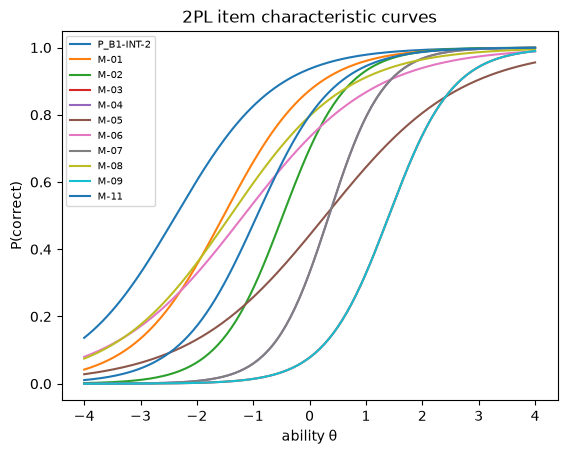

In [10]:
th = np.linspace(-4, 4, 200)
for iid in keep:
    plt.plot(th, expit(stats.loc[iid, "a_2pl"] * (th - stats.loc[iid, "b_2pl"])), label=iid)
plt.xlabel("ability θ"); plt.ylabel("P(correct)"); plt.title("2PL item characteristic curves"); plt.legend(fontsize=7)
plt.show()

## Empirical vs. predicted difficulty

The Rasch difficulty (higher = harder) and the facility (higher = easier) against the prediction
from Notebook 3, overall and by category (reading items only — the math items have no prediction;
for them the last cell shows which misconception each chosen distractor encodes). Two things to discuss: the "population" is a handful of
prompted personas, and the predictor was trained on human response data — a low correlation
says as much about the artificial test-takers as about the predictor.

In [11]:
stats["predicted"] = [predicted.get(i) for i in item_ids]
ok = stats["predicted"].notna() & stats["b_rasch"].notna()
if ok.sum() >= 3 and stats.loc[ok, "b_rasch"].std() > 0 and stats.loc[ok, "predicted"].std() > 0:
    print(f"predicted vs Rasch b:   r = {pearsonr(stats.loc[ok, 'predicted'], stats.loc[ok, 'b_rasch'])[0]:.2f}, "
          f"rho = {spearmanr(stats.loc[ok, 'predicted'], stats.loc[ok, 'b_rasch'])[0]:.2f}")
    print(f"predicted vs facility:  r = {pearsonr(stats.loc[ok, 'predicted'], stats.loc[ok, 'facility'])[0]:.2f}")
    for cat, grp in stats[ok].groupby("cat"):
        plt.scatter(grp["predicted"], grp["b_rasch"], label=cat)
    plt.xlabel("predicted difficulty (CMCQRD scale)"); plt.ylabel("Rasch b"); plt.legend(); plt.show()
else:
    print("no variance in the empirical difficulties - nothing to correlate")
print(stats.groupby("cat")[["facility", "b_rasch", "predicted"]].mean().round(2))

# math items: which misconception did the wrong answers go to?
math_ids = [i for i in item_ids if by_id[i].get("cat") == "MATH"]
if math_ids:
    rows = []
    for iid in math_ids:
        mis = by_id[iid].get("template", {}).get("misconceptions", {})
        for L, name in mis.items():
            if name != "key":
                rows.append({"item": iid, "misconception": name, "share": float((choices[iid] == L).mean())})
    print("\nshare of test-takers choosing each misconception (math items):")
    print(pd.DataFrame(rows).groupby("misconception")["share"].mean().round(2))

with open("day2_analysis.json", "w", encoding="utf-8") as f:
    json.dump({"alpha": None if np.isnan(alpha) else float(alpha), "alpha_by_booklet": {k: (None if np.isnan(v) else float(v)) for k, v in alpha_by_booklet.items()},
               "items": stats.reset_index().to_dict(orient="records"),
               "distractors": distractor_table().to_dict(orient="records")}, f, indent=1, default=float)
print("saved day2_analysis.json")

no variance in the empirical difficulties - nothing to correlate
      facility  b_rasch  predicted
cat                               
CRIT      1.00      NaN      66.27
FR        1.00      NaN      64.64
INF       1.00      NaN      66.95
INT       0.95    -2.56      65.76
MATH      0.52    -0.11        NaN

share of test-takers choosing each misconception (math items):
misconception
absolute difference    0.13
remaining fraction     0.18
wrong base             0.18
Name: share, dtype: float64
saved day2_analysis.json


## Four more looks at the matrix (offline)

None of the cells below calls the endpoint: they only re-read the response matrix and the files from
Notebook 3, so they run from the cache. They are the starting points for the work time and the
show-and-tell.

### 1 · What does low ability look like?

A small model can score low for three different reasons: it chooses wrong options, it answers
outside A–D (scored as wrong above), or it prefers one letter whatever the item says. The first table
shows the share of answers outside A–D per persona. The second shows how often each persona chooses
each letter, with the last row giving how often each letter is the key. If a persona's letter profile
is flat or stuck on one letter, its "difficulties" partly track the position of the key.

In [12]:
persona = scored["persona"]
print("share of answers outside A-D (scored as wrong), by persona:")
print(choices.isna().mean(axis=1).groupby(persona).mean().round(2), "\n")

letter_share = pd.DataFrame({L: (choices == L).sum(axis=1) for L in "ABCD"}).groupby(persona).sum()
letter_share = letter_share.div(letter_share.sum(axis=1).replace(0, np.nan), axis=0)
key_share = pd.Series(keys).value_counts(normalize=True).reindex(list("ABCD"), fill_value=0)
print("share of each letter among the valid answers, by persona (last row: share of keys):")
pd.concat([letter_share, key_share.rename("keys").to_frame().T]).round(2)

share of answers outside A-D (scored as wrong), by persona:
persona
A2    0.0
B1    0.0
B2    0.0
C1    0.0
C2    0.0
dtype: float64 

share of each letter among the valid answers, by persona (last row: share of keys):


,A,B,C,D
A2,0.64,0.12,0.14,0.10
B1,0.52,0.25,0.10,0.12
B2,0.51,0.25,0.09,0.15
C1,0.55,0.25,0.05,0.15
C2,0.45,0.25,0.05,0.25
keys,0.45,0.25,0.05,0.25


### 2 · Did the screening predict how the items behave?

Notebook 3 flagged items but kept them. If its checks capture something real, the items that passed
should show more sensible facilities and higher item–rest correlations than the flagged ones. With
twenty items and twenty test-takers, read this as a hint, not as a test. The second table lists the
flagged items with the checks they failed.

In [13]:
PASS = 7                                                     # the threshold used in Notebook 3


def failed_checks(item):
    s = item.get("screening", {})
    out = list(s.get("rule_fails", []))
    for k, v in s.items():
        if isinstance(v, bool) or not isinstance(v, (int, float)):
            continue
        if (k == "max_defensible" and v >= PASS) or (k != "max_defensible" and v < PASS):
            out.append(k)
    return out


print(stats.groupby("screened_ok")[["facility", "rpb", "b_rasch"]].agg(["mean", "count"]).round(2), "\n")
flagged = stats[stats["screened_ok"] == False]
pd.DataFrame({"cat": flagged["cat"], "facility": flagged["facility"].round(2), "rpb": flagged["rpb"].round(2),
              "failed": [", ".join(failed_checks(by_id[i])) for i in flagged.index]})

            facility         rpb       b_rasch      
                mean count  mean count    mean count
screened_ok                                         
False           0.67    15  0.54    11   -0.33    11
True            1.00     5   NaN     0     NaN     0 



,cat,facility,rpb,failed
P_B1-FR-2,FR,1.00,NaN,vague_words
P_B1-INT-2,INT,0.90,0.24,logical_cues
P_B2-FR-1,FR,1.00,NaN,logical_cues
P_B2-INT-1,INT,1.00,NaN,absolute_words_in_distractors
P_C1-INF-3,INF,1.00,NaN,solvability
M-01,MATH,0.80,0.44,grammatical_cues
M-02,MATH,0.60,0.72,grammatical_cues
M-03,MATH,0.20,0.74,grammatical_cues
M-04,MATH,0.40,0.86,"logical_cues, grammatical_cues"
M-05,MATH,0.45,0.25,grammatical_cues


### 3 · Functioning distractors

A common rule of thumb (Haladyna & Downing, 1993) calls a distractor *functioning* when at least 5 %
of the test-takers choose it; with twenty test-takers that is one person. `both` additionally asks
that the weakest 27 % choose it more often than the strongest 27 %, as a distractor should. The first
line is the number for the show-and-tell slide.

In [14]:
MIN_SHARE = 0.05

dis = distractor_table()
dis = dis[~dis["key"]].copy()
dis["functioning"] = dis["share"] >= MIN_SHARE
dis["both"] = dis["functioning"] & (dis["share_weak"] > dis["share_strong"])
per_item = dis.groupby("item")[["functioning", "both"]].sum().astype(int).reindex(item_ids)
per_item.insert(0, "cat", [by_id[i]["cat"] for i in per_item.index])
has_one = per_item["functioning"] > 0
print(f"items with at least one functioning distractor: {has_one.mean():.0%} ({int(has_one.sum())} of {len(per_item)})")
print("by category:", per_item.assign(has_one=has_one).groupby("cat")["has_one"].mean().round(2).to_dict())
per_item

items with at least one functioning distractor: 55% (11 of 20)
by category: {'CRIT': 0.0, 'FR': 0.0, 'INF': 0.0, 'INT': 0.5, 'MATH': 1.0}


,cat,functioning,both
item,,,
P_B1-FR-2,FR,0,0
P_B1-INF-1,INF,0,0
P_B1-INT-2,INT,1,1
P_B1-CRIT-1,CRIT,0,0
P_B2-FR-1,FR,0,0
P_B2-INF-1,INF,0,0
P_B2-INT-1,INT,0,0
P_B2-CRIT-1,CRIT,0,0
P_C1-FR-1,FR,0,0


### 4 · Your dial for the show-and-tell

Everyone replays the same cache, so without a change every pair gets the same correlation. Each pair
changes **one** setting below, runs the cell and reports r. The 95 % interval (Fisher z) shows how
much ten items can say.

* `EXCLUDE_LEVELS = ["C2"]` drops the C2 test-takers, i.e. the model that wrote and judged the items;
  the IRT model is refitted without them.
* `ONLY_SCREENED = True` keeps only the items that passed every check in Notebook 3.
* `EMPIRICAL` chooses the empirical difficulty: Rasch b, 2PL b, or facility (higher = easier, so expect
  a negative r).
* A different predictor: in Notebook 3, set `best` to `"handcrafted"`, `"embedding"` or `"all"` before
  the last cell, re-run it, then re-run this notebook from the top.

In [15]:
EXCLUDE_LEVELS = []              # e.g. ["C2"]
ONLY_SCREENED  = False           # True: only items that passed every check in Notebook 3
EMPIRICAL      = "b_rasch"       # "b_rasch", "b_2pl" or "facility"

rows = [t for t in S.index if scored.loc[t, "persona"] not in EXCLUDE_LEVELS]
X = S.loc[rows]
emp = pd.Series(np.nan, index=item_ids)
if EMPIRICAL == "facility":
    emp = X.mean()
else:
    var = [i for i in item_ids if 0 < X[i].mean() < 1]           # items with variance among these test-takers
    if len(var) >= 2:
        emp[var] = fit_irt(X[var].values, "2PL" if EMPIRICAL == "b_2pl" else "Rasch")["b"]

cols = [i for i in item_ids if predicted.get(i) is not None                     # reading items (math: no prediction)
        and (not ONLY_SCREENED or by_id[i].get("screening", {}).get("passed"))]
pairs = pd.DataFrame({"cat": [by_id[i]["cat"] for i in cols], "predicted": [predicted[i] for i in cols],
                      EMPIRICAL: emp.reindex(cols).values}, index=cols).dropna()
n = len(pairs)
if n >= 4 and pairs[EMPIRICAL].std() > 0 and pairs["predicted"].std() > 0:
    r = float(np.clip(pearsonr(pairs["predicted"], pairs[EMPIRICAL])[0], -0.999, 0.999))
    z, se = np.arctanh(r), 1 / np.sqrt(n - 3)
    print(f"r(predicted, {EMPIRICAL}) = {r:.2f}, 95% CI [{np.tanh(z - 1.96 * se):.2f}, {np.tanh(z + 1.96 * se):.2f}]"
          f"  -  {n} items, {len(rows)} test-takers, excluded levels: {EXCLUDE_LEVELS or 'none'}")
else:
    print(f"{n} items with an empirical value and some variance - too few to correlate")
pairs.round(2)

1 items with an empirical value and some variance - too few to correlate


,cat,predicted,b_rasch
P_B1-INT-2,INT,64.34,-2.56
